# Notebook 4: multi-maturity densities and dynamic 3D graphs

This experiment is synthetic. The executable cell rebuilds the data, figures and offline explorer. Open `interactive/density_surface.html` in a browser for rotation, zoom, hover and maturity selection. The first three notebooks are unchanged. Rerun this builder after changing the experiment to refresh the embedded figures.


# Extending density recovery across expiry horizons
## Milestone 4: a synthetic surface and interactive research companion
Joel Cerraga | Quant research project | Development version 0.4

**Status:** eight synthetic maturity slices have been fitted and visualised. Each is a valid constrained marginal distribution. Their combination is **not** an arbitrage-free fitted term structure: the diagnostic below finds calendar inconsistencies in extrapolated wings. No candidate market quotes are calibrated in this milestone.

### 1. What the third dimension represents

The previous experiment recovered a distribution for one expiry. The subsequent task involved repeating that calculation at several horizons, while retaining a common initial index level and valuation setup. The three axes are terminal index level, time to expiry and risk-neutral density. There is no sequence of observation dates in this experiment.

As Bahra (1997) explains in his Bank of England working paper [1, §§2.1–2.2], option-implied densities are distributions under the risk-neutral measure. In the lognormal benchmark, uncertainty increases with the horizon through the volatility-time term. This provides an interpretable starting point for comparing expiries; it does not turn the recovered densities into physical-probability forecasts.

The interactive companion permits rotation, zoom, numerical hover inspection, switching between the fitted and known surfaces, and a linked maturity slice. Its play control visits the eight expiry horizons once. **A maturity sweep is not a historical market animation.** The latter remains a planned extension, conditional on obtaining suitable date-stamped market snapshots and aligning their expiry horizons.

### 2. Experiment design

The starting level remains 6,000, with annualised volatility of 20%, a continuously compounded rate of 4% and a continuous dividend yield of 1.5%. The synthetic horizons are 30, 60, 90, 120, 180, 240, 300 and 365 days, divided by 365 to obtain years. These are model horizons, not verified SPX settlement dates; 180/365 is not the half-year maturity used in Milestone 3.

For each horizon, 81 equally spaced strikes run from $F\exp(-2.5\sigma\sqrt{T})$ to $F\exp(2.5\sigma\sqrt{T})$. This deliberately uses the known benchmark volatility to construct a synthetic quote grid. It is not a proposed market-data selection rule. Each price receives an independent uniform perturbation between −0.5 and +0.5 index points, using seed `20260920 + horizon_days`. The error has zero mean and standard deviation $1/\sqrt{12}$, approximately 0.288675 index points. The seed is an integer rule, not an observation date.

The bounded perturbation differs from the earlier Gaussian stress test. It permits a controlled experiment at short maturities without clipping negative prices. Every generated price is checked and the runner stops if a negative input occurs. These errors do not preserve all option-price constraints and are not calibrated market microstructure noise.

The fitter retains Equations (9)–(12): 120 equal-width intervals on $[0.3F(T),2.2F(T)]$, unit mass, nonnegative probabilities and the supplied forward as the mean. The penalty remains $10^{-6}$ for every expiry, with no maturity-specific tuning. As Boyd and Vandenberghe discuss in *Convex Optimization* [11, §6.3], regularisation balances data agreement and smoothness; using one setting here permits a transparent comparison rather than establishing an optimal setting.

### 3. Checking consistency between expiries

As Gatheral and Jacquier explain in *Arbitrage-free SVI volatility surfaces* [12, §2], admissible individual slices and consistency across maturities are distinct requirements. We use their martingale argument in §2.1, not their SVI parameterisation. With deterministic carry and proportional dividends, define forward moneyness $\kappa=K/F(T)$ and normalise Equation (1):

$$\overline C(\kappa,T)=\frac{C(\kappa F(T),T)}{D(T)F(T)}=\mathbb{E}^{Q}\!\left[\left(\frac{S_T}{F(T)}-\kappa\right)_+\right].\tag{13}$$

Here, $\kappa$ is a strike-to-forward ratio, not log-moneyness. Equation (13) explicitly retains discounting in the project's notation. For the same $\kappa$ at increasing horizons, the conditional convexity argument applied to the normalised martingale gives:

$$\overline C(\kappa,T_{i+1})\geq\overline C(\kappa,T_i),\qquad T_{i+1}>T_i.\tag{14}$$

Equation (14) is checked at 1,901 equally spaced ratios from 0.3 to 2.2 for each adjacent horizon pair. A decrease greater than $10^{-8}$ is counted as a violation. This is a sampled diagnostic, not a constraint in the estimator or a proof covering every strike. Comparing raw calls at a fixed absolute strike would not implement this normalised test.

### 4. Measuring the recovered slices

We compare fitted call prices with known prices at the 80 interleaved strikes withheld from each fit. This remains a synthetic interpolation check. The density discrepancy on the fitting support is:

$$L_1(T)=\int_{a_1(T)}^{b_J(T)}\left|\widehat f_Q(s;T)-f_Q(s;T)\right|\,ds.\tag{15}$$

Equation (15) defines the project's reported error measure; it is dimensionless and is not a pointwise percentage error. It is evaluated numerically on 40,001 levels. The known density's probability outside the finite fitting support is reported separately rather than silently discarded or renormalised.



In [1]:
from run_surface import main
from build_surface_html import main as build_explorer
result = main()
explorer = build_explorer()


{
  "status": "synthetic_only",
  "observation_dates": null,
  "base_parameters": {
    "spot": 6000.0,
    "rate": 0.04,
    "dividend": 0.015,
    "volatility": 0.2
  },
  "days": [
    30,
    60,
    90,
    120,
    180,
    240,
    300,
    365
  ],
  "day_count": "synthetic horizon / 365, not a contract settlement calculation",
  "noise": {
    "distribution": "independent uniform",
    "bounds": [
      -0.5,
      0.5
    ],
    "standard_deviation": 0.2886751345948129,
    "seed_rule": "20260920 + horizon_days"
  },
  "quotes_per_maturity": 81,
  "bins_per_maturity": 120,
  "penalty": 1e-06,
  "penalty_selection": "Retained Milestone 3 baseline for every maturity; no maturity-specific tuning",
  "strike_rule": "81 equally spaced strikes between F exp(-2.5 sigma sqrt(T)) and F exp(2.5 sigma sqrt(T))",
  "support_rule": "120 equal-width bins on [0.3 F(T), 2.2 F(T)]",
  "display_range": [
    3000.0,
    11000.0
  ],
  "display_interpolation": "Straight graphical joins only; no

Table 7. Synthetic validation by expiry horizon. RMSE is measured in index points; $L_1$ and probability mass are dimensionless.

| Horizon (days) | Withheld clean-price RMSE | Density $L_1$ on support | Known probability outside support |
|---|---:|---:|---:|
| 30 | 0.127809 | 0.058293 | $1.6893\times10^{-43}$ |
| 60 | 0.109230 | 0.042719 | $8.0373\times10^{-23}$ |
| 90 | 0.131872 | 0.036594 | $6.8132\times10^{-16}$ |
| 120 | 0.096013 | 0.030898 | $2.0625\times10^{-12}$ |
| 180 | 0.083350 | 0.027398 | $6.5773\times10^{-9}$ |
| 240 | 0.149516 | 0.026950 | $3.8505\times10^{-7}$ |
| 300 | 0.105392 | 0.025826 | $4.5167\times10^{-6}$ |
| 365 | 0.137777 | 0.032580 | $2.6468\times10^{-5}$ |

All eight fits have unit mass and forward-consistent means to numerical tolerance, nonnegative bin probabilities, and no sampled strike-monotonicity or convexity violations. These checks confirm the imposed marginal restrictions; Table 7 separately measures agreement with the known answer. Results are generated by this project, not taken from the references.

### 5. Reading the surface



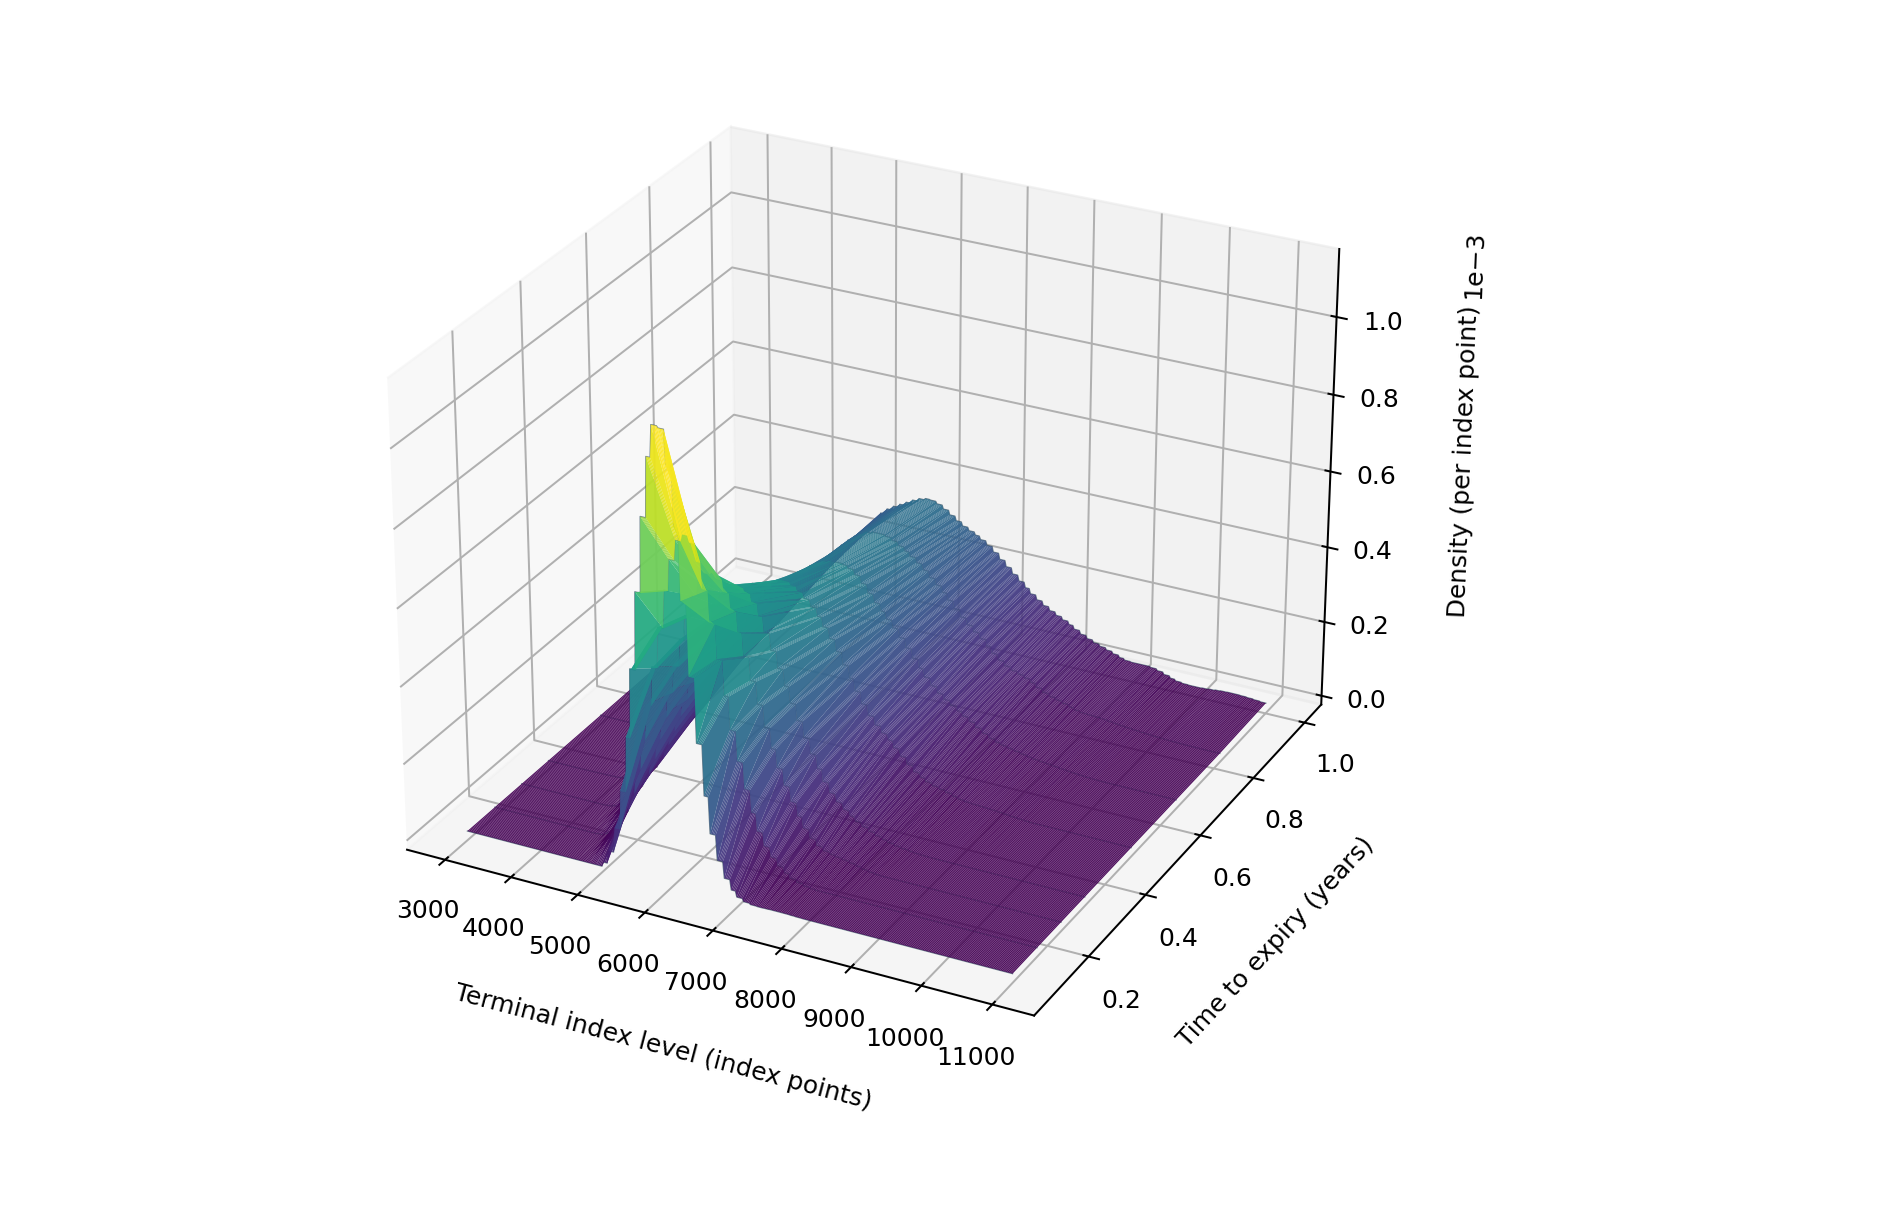




Figure 10. Constrained synthetic densities at eight horizons from 30 to 365 days, displayed over terminal levels 3,000–11,000. The sheet joins sampled values for visual orientation; it is not a fitted interpolation model between maturities. Density is measured per index point. The interactive companion adds rotation, zoom, hover values and maturity selection.

As shown in Figure 10, the short-horizon distribution is more concentrated, while longer-horizon distributions cover a wider range of index levels. The decreasing peak does not indicate a loss of total probability. Probability is obtained by integrating each density with respect to the terminal level, not by comparing peak heights or treating the surface as a joint distribution over expiry and index level.

The fitting support is wider than the display. The graph contains approximately 99.8934%–100% of the fitted mass, depending on the horizon. Values are not renormalised to the cropped window. The underlying histogram remains piecewise constant; the rendered sheet visually joins sampled values in both directions. Intermediate heights on that sheet must not be used as additional estimated densities.



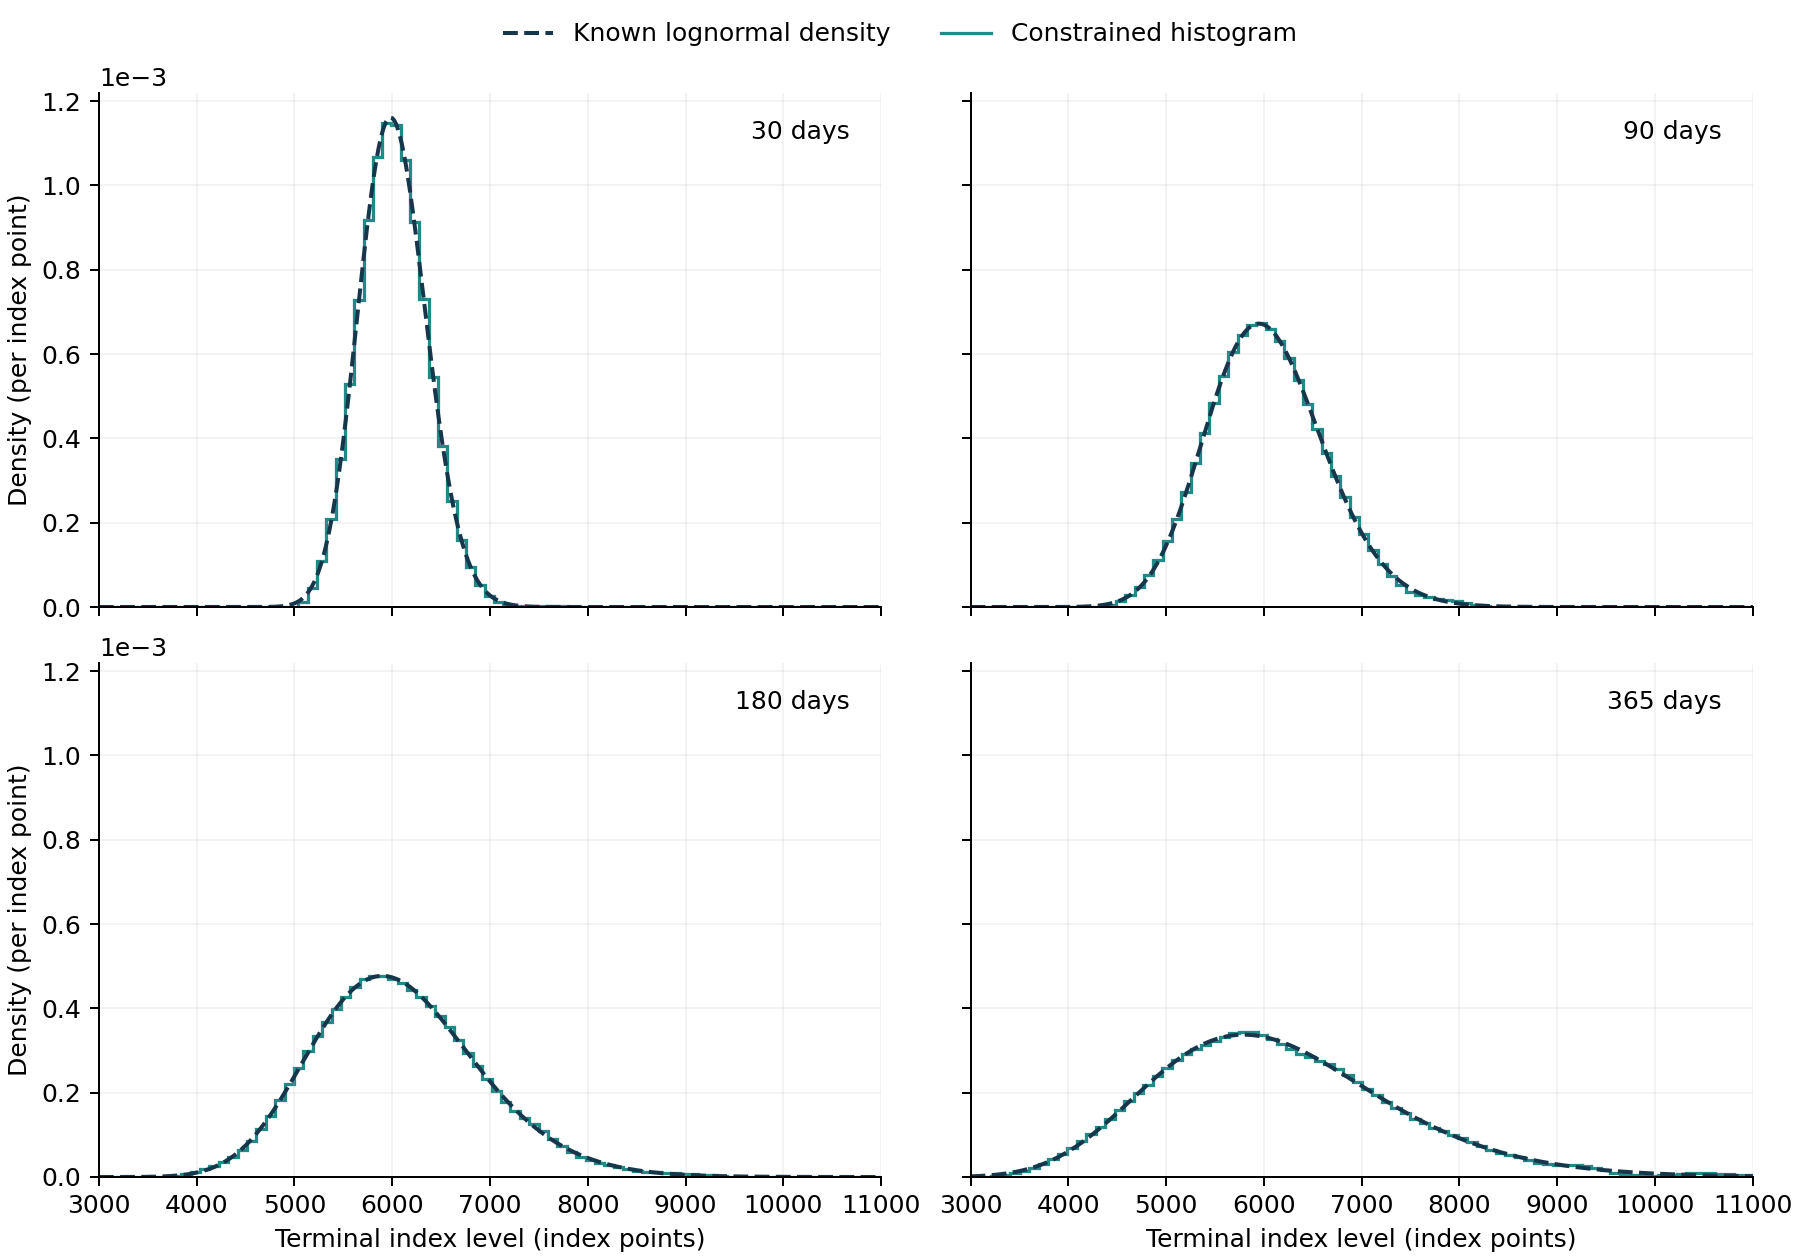




Figure 11. Known lognormal densities and fitted histogram slices at 30, 90, 180 and 365 days. All panels use the same axes. The stepwise density is the actual interval representation, without display smoothing. The interactive companion permits selection of all eight fitted horizons.

Figure 11 makes it easier to inspect the density shapes without the perspective and occlusion of a three-dimensional view. The 2D companion is therefore retained alongside the 3D graph. Open [the offline interactive explorer](interactive/density_surface.html) in a browser after extracting the project. Its saved data and plotting code are embedded; Python is needed only to regenerate the experiment.

### 6. What the cross-maturity check reveals

Table 8. Adjacent-maturity calendar diagnostic on the finite grid in Equation (14). The minimum change is in normalised, dimensionless call value.

| Horizons (days) | Violations across full grid | Minimum normalised change | Violations within shared quote range |
|---|---:|---:|---:|
| 30 → 60 | 0 | $-4.44\times10^{-16}$ | 0 |
| 60 → 90 | 723 | $-5.42381\times10^{-5}$ | 0 |
| 90 → 120 | 393 | $-3.59782\times10^{-5}$ | 0 |
| 120 → 180 | 823 | $-8.97400\times10^{-5}$ | 0 |
| 180 → 240 | 0 | 0 | 0 |
| 240 → 300 | 309 | $-6.68342\times10^{-5}$ | 0 |
| 300 → 365 | 514 | $-1.90808\times10^{-4}$ | 0 |

There are 2,762 violations among 13,307 full-grid comparisons. None occurs among the 4,267 comparisons lying inside both members' normalised quote ranges. The known analytical prices have no violations at the stated tolerance. Tiny changes of order $10^{-16}$ are floating-point effects, below that tolerance.

The fitted violations are in the extrapolated wings, where at least one slice lacks direct quote coverage. Their location is an observed result of this experiment, not a universal claim about independently fitted densities. The largest decrease is approximately 0.000190808 in normalised call value. These are correlated grid checks, not 2,762 independent arbitrage opportunities or a percentage of invalid probability mass.

The outcome shows why good price interpolation and valid marginal distributions are insufficient to label an entire fitted surface arbitrage-free. No offending values have been clipped, removed or adjusted after fitting. Joint calendar-constrained estimation and more extensive tail-support tests are the next numerical steps.

### 7. Planned dynamic visualisation and empirical work

The project now includes the first dynamic 3D companion. Later versions should add verified market maturity surfaces, followed by observation-date animation only when multiple suitable snapshots are available. The historical view must distinguish changing dates from changing time to expiry, show missing horizons explicitly, and document any interpolation used to align them. It is not yet implemented.

The market-data blockers recorded in `data_access_status.md` remain: observation timestamp meaning/timezone, suitable quote fields and settlement consistency. This milestone neither resolves those questions nor supplies historical returns, forecasting performance or a trading strategy.

The final paper will include static, numbered figures and a reference to the interactive supplement. Its title page, abstract, contents, lists of figures/tables/equations, abbreviations and mathematical symbols remain tracked in `paper_registers.md`. The earlier Figure 4 → caption → explanation order is unchanged.

### References

[1] B. Bahra (1997), “Implied risk-neutral probability density functions from option prices: theory and application,” Bank of England, Working Paper No. 66. [Full paper](https://www.bankofengland.co.uk/-/media/boe/files/working-paper/1997/implied-risk-neutral-probability-density-functions-from-option-prices.pdf).

[11] S. Boyd and L. Vandenberghe (2004), *Convex Optimization*. Cambridge University Press, §6.3. [Author-hosted book](https://web.stanford.edu/~boyd/cvxbook/bv_cvxbook.pdf).

[12] J. Gatheral and A. Jacquier, “Arbitrage-free SVI volatility surfaces,” *Quantitative Finance*, vol. 14, no. 1, pp. 59–71; first published online 2013. [doi:10.1080/14697688.2013.819986](https://doi.org/10.1080/14697688.2013.819986). The consulted text is the [author preprint, arXiv:1204.0646v4](https://arxiv.org/abs/1204.0646v4), §2, particularly §2.1 and Lemma 2.1. This project's explicit discount normalisation is stated in Equation (13).
